In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

Библиотеки импортированы!


In [3]:
# Загружаем уже разделенные файлы
train_raw = pd.read_csv('../data/raw/transactions_train.csv')
test_df = pd.read_csv('../data/raw/transactions_test.csv')

print(f"Размер исходного Train: {train_raw.shape[0]} строк и {train_raw.shape[1]} столбцов.")
print(f"Размер исходного Test:  {test_df.shape[0]} строк и {test_df.shape[1]} столбцов.")

TARGET_COL = 'is_fraud'
DATE_COL = 'transaction_time'

Размер исходного Train: 300113 строк и 21 столбцов.
Размер исходного Test:  99887 строк и 21 столбцов.


In [4]:
def clean_data(df, dataset_name="Data"):
    print(f"Очистка {dataset_name} ")
    
    # 1. Дубликаты
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        df = df.drop_duplicates()
        print(f"Удалено дубликатов: {duplicates}")
    else:
        print("Дубликатов не найдено.")
        
    # 2. Пропуски (на случай, если они есть)
    missing = df.isnull().sum()
    missing_cols = missing[missing > 0]
    if not missing_cols.empty:
        for col in missing_cols.index:
            if df[col].dtype in['float64', 'int64']:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna('Unknown')
        print(f"Заполнены пропуски в колонках: {list(missing_cols.index)}")
        
    # 3. Data Leakage
    if 'post_auth_risk_score' in df.columns:
        df = df.drop(columns=['post_auth_risk_score'])
        print("Удалена колонка-утечка 'post_auth_risk_score'.")
        
    return df

train_clean = clean_data(train_raw, "Train")
test_df = clean_data(test_df, "Test")


--- Очистка Train ---
Дубликатов не найдено.
Удалена колонка-утечка 'post_auth_risk_score'.

--- Очистка Test ---
Дубликатов не найдено.
Удалена колонка-утечка 'post_auth_risk_score'.


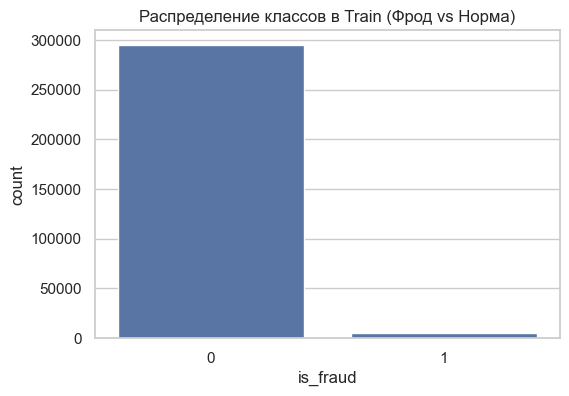

Доля фрода в Train: 1.62% (сильный дисбаланс!)


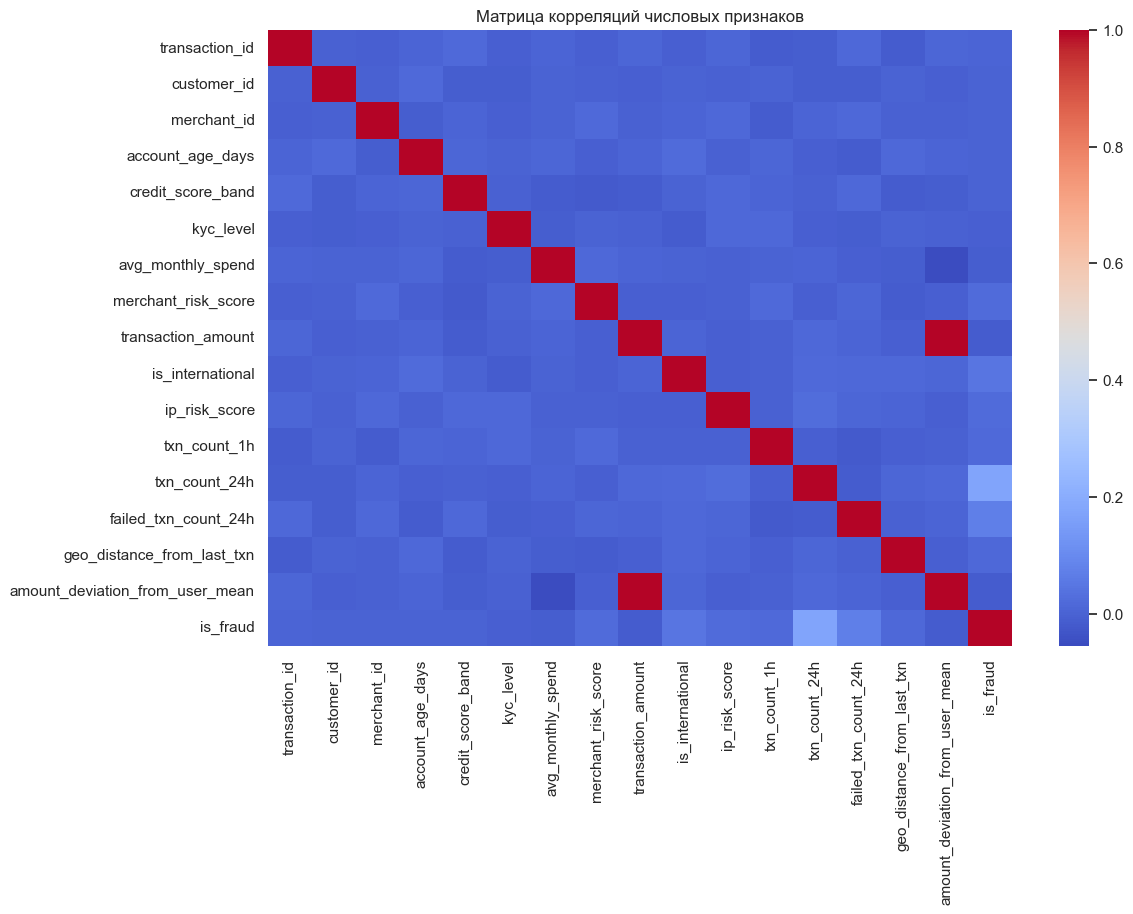

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_clean, x=TARGET_COL)
plt.title('Распределение классов в Train (Фрод vs Норма)')
plt.show()

fraud_ratio = train_clean[TARGET_COL].mean() * 100
print(f"Доля фрода в Train: {fraud_ratio:.2f}% (сильный дисбаланс!)")

# Матрица корреляций
plt.figure(figsize=(12, 8))
numeric_cols = train_clean.select_dtypes(include=[np.number]).columns
sns.heatmap(train_clean[numeric_cols].sample(10000, random_state=42).corr(), 
            annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций числовых признаков')
plt.show()

In [6]:
# Убеждаемся, что дата в нужном формате
train_clean[DATE_COL] = pd.to_datetime(train_clean[DATE_COL])
test_df[DATE_COL] = pd.to_datetime(test_df[DATE_COL])

# Сортируем Train по времени
train_clean = train_clean.sort_values(by=DATE_COL).reset_index(drop=True)

# Отщепляем последние 20% от train_clean на Validation (примерно сентябрь)
n_total_train = len(train_clean)
val_split_index = int(n_total_train * 0.8)

train_df = train_clean.iloc[:val_split_index]
val_df = train_clean.iloc[val_split_index:]

print("Итоговые размеры выборок (Strict Time-based Split):")
print(f"Train: {train_df.shape[0]} строк (с {train_df[DATE_COL].min().date()} по {train_df[DATE_COL].max().date()})")
print(f"Val:   {val_df.shape[0]} строк (с {val_df[DATE_COL].min().date()} по {val_df[DATE_COL].max().date()})")
print(f"Test:  {test_df.shape[0]} строк (с {test_df[DATE_COL].min().date()} по {test_df[DATE_COL].max().date()})")

Итоговые размеры выборок (Strict Time-based Split):
Train: 240090 строк (с 2023-01-01 по 2023-08-07)
Val:   60023 строк (с 2023-08-07 по 2023-09-30)
Test:  99887 строк (с 2023-10-01 по 2023-12-30)


In [7]:
# Разделяем фичи и таргет, удаляем ID транзакций и дату
cols_to_drop =[TARGET_COL, DATE_COL, 'transaction_id', 'customer_id', 'merchant_id']

X_train = train_df.drop(columns=cols_to_drop, errors='ignore')
y_train = train_df[TARGET_COL]

X_val = val_df.drop(columns=cols_to_drop, errors='ignore')
y_val = val_df[TARGET_COL]

X_test = test_df.drop(columns=cols_to_drop, errors='ignore')
y_test = test_df[TARGET_COL]

import os
os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Все готово! Train, Val и Test сохранены в папке ../data/processed/")

Все готово! Train, Val и Test сохранены в папке ../data/processed/
